In [1]:
import gc

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm
import gc

In [2]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [6]:
ON0092_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"
ON0096_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"
ON0099_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"
ON0118_df = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0118/ON0118/result/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"


In [7]:
df_dict = {"A rep. 1": pd.read_pickle(ON0092_df_path),
           "A rep. 2": pd.read_pickle(ON0096_df_path),
           "m6A rep. 1": pd.read_pickle(ON0099_df_path),
           "m6A rep. 2": pd.read_pickle(ON0118_df)}

In [8]:
## Groupby 5mer and calculate mean signal
def get_motif_signal(df_dict, key = "5mer"):
    motif_dict = {}
    for k in df_dict.keys():
        df = df_dict[k]
        # motif_df = df[["bq_centre", "signal_centre", "bq_avg", "signal_avg",  "signal_3mer",  "signal_5mer",  "signal_7mer", 'signal_9mer','signal_11mer', key]].groupby(key).mean()
        motif_df = df[["bq_centre", "signal_centre", "bq_avg", "signal_avg", key]].groupby(key).mean()
        motif_count_df = df[key].value_counts()
        motif_df = pd.merge(motif_df, motif_count_df, left_index = True, right_index = True)
        motif_dict[k] = motif_df
    return motif_dict

In [9]:
for df in df_dict.values():
    df["9mer"] = df["motif"].apply(lambda x: x[6:15])

In [10]:
dict_9mer = get_motif_signal(df_dict, key = "9mer")

In [27]:
## Plot scatter : ON0092 vs. ON0096
plt.rcParams.update({'font.size': 24})

from scipy import stats

def get_density(x,y, sample=1000, bw_method= 0.2):
    values = np.stack([x, y], axis=0)
    sampled = values
    sampled = sampled[:, np.random.choice(sampled.shape[1], sample, replace=False)]
    kernel = stats.gaussian_kde(sampled, bw_method=bw_method)
    density = kernel(values)
    density = np.clip(density, None, np.percentile(density[x>0], 99))
    return density

def plot_scatter(ax, df_dict, k1, k2, feature = "signal_avg", x_label = None, y_label = None, min_count = 100, no_density = False):

    merged_df = pd.merge(df_dict[k1][df_dict[k1]["count"] > min_count][[feature]],
                         df_dict[k2][df_dict[k2]["count"] > min_count][[feature]],
                         how = "inner", left_index = True, right_index = True).dropna()
    merged_df = merged_df[[f"{feature}_x", f"{feature}_y"]]
    merged_df.columns = [k1, k2]

    if no_density:
        sns.scatterplot(x = k1, y = k2, data = merged_df, ax = ax, legend=False, linewidth=0, c = "royalblue")

    else:
        density = get_density(merged_df[k1], merged_df[k2], sample=10000, bw_method=0.3)
        sns.scatterplot(x = k1, y = k2, data = merged_df, ax = ax,
                        cmap=sns.color_palette("flare_r", as_cmap=True), legend=False, linewidth=0, c = density)

    r2 = stats.pearsonr(merged_df[k1], merged_df[k2])[0]**2
    rho2 = stats.spearmanr(merged_df[k1], merged_df[k2])[0]**2
    min_val = min(np.min(merged_df[k1]), np.min(merged_df[k2]))
    max_val = max(np.max(merged_df[k1]), np.max(merged_df[k2]))
    # ax.set_xlabel(x_label if x_label else k1)
    # ax.set_ylabel(y_label if y_label else k2)
    ax.text(0.05,0.95, f"R2 ={r2:.3f}\nRho2={rho2:.3f}", fontsize=24, transform=ax.transAxes, ha = "left", va = "top")
    ax.patch.set_alpha(0)
    ax.patch.set_facecolor('none')
    return min_val, max_val

In [28]:
from matplotlib import ticker
def plot_all_combinations(df_dict, feature = "signal_avg", tick = 0.5, no_density = False):
    fig, axes = plt.subplots(4,4, figsize = (40,40))
    min_vals = []
    max_vals = []
    with tqdm.tqdm(total = len(df_dict.keys())**2) as pbar:
        for i, k1 in enumerate(df_dict.keys()):
            for j, k2 in enumerate(df_dict.keys()):
                pbar.update(1)
                if k1 == k2:
                    axes[j,i].text(0.5, 0.5, k1, fontsize = 48, ha = "center", va = "center", transform = axes[j,i].transAxes)
                    continue
                min_val, max_val = plot_scatter(axes[j,i], df_dict, k1, k2, feature = feature,
                                                x_label = k1, y_label = k2, no_density = no_density)
                min_vals.append(min_val)
                max_vals.append(max_val)
    min_val = min(min_vals)
    max_val = max(max_vals)
    for ax in axes.flatten():
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(tick))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(tick))
        ax.set_aspect('equal')
        ax.grid(False)
    plt.suptitle(f"Reproducibility of {feature} in 9mer motif")
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/reprod_9mer_manu_{feature}.png", transparent=True, dpi=300)
    ## Remove texts in each ax and save
    for ax in axes.flatten():
        for text in ax.texts:
            text.set_visible(False)
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/reprod_9mer_manu_{feature}_notext.png", transparent=True, dpi=300)

    for ax in axes.flatten():
        for text in ax.texts:
            text.set_visible(True)

    plt.show()

    return None


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [03:08<00:00, 11.80s/it]


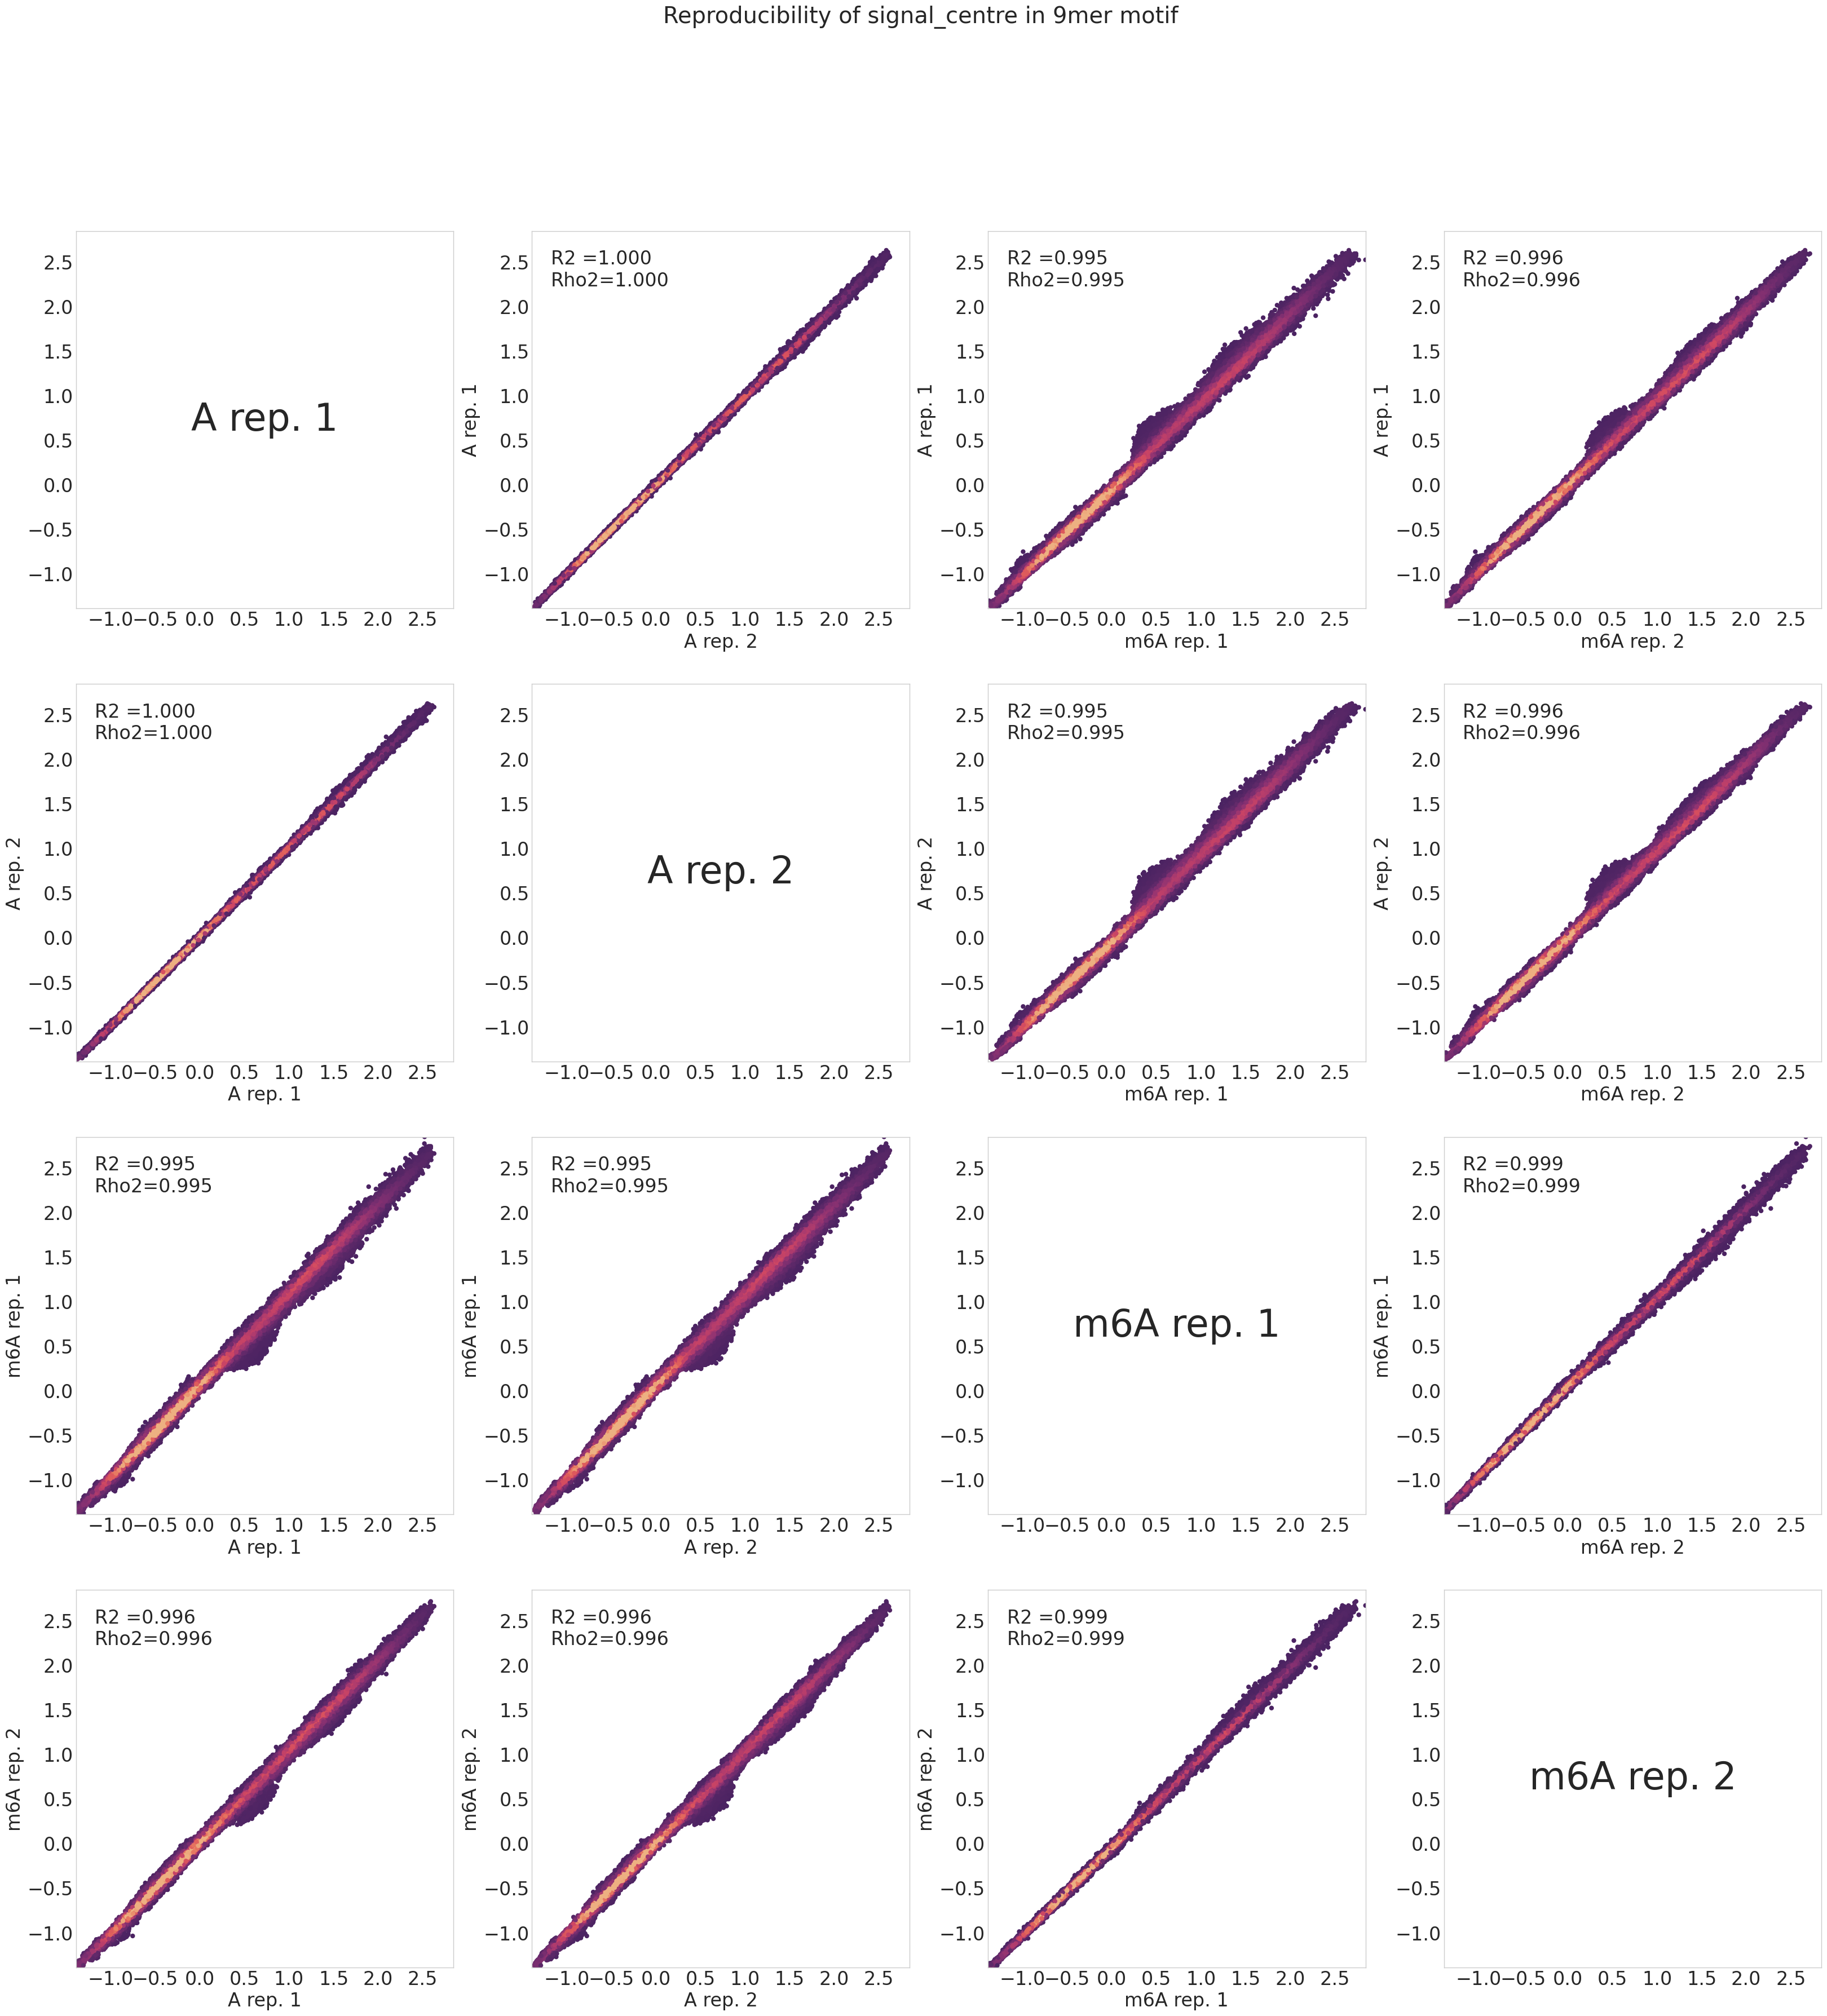

In [29]:
plot_all_combinations(dict_9mer, feature = "signal_centre", tick = 0.5)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [03:09<00:00, 11.87s/it]


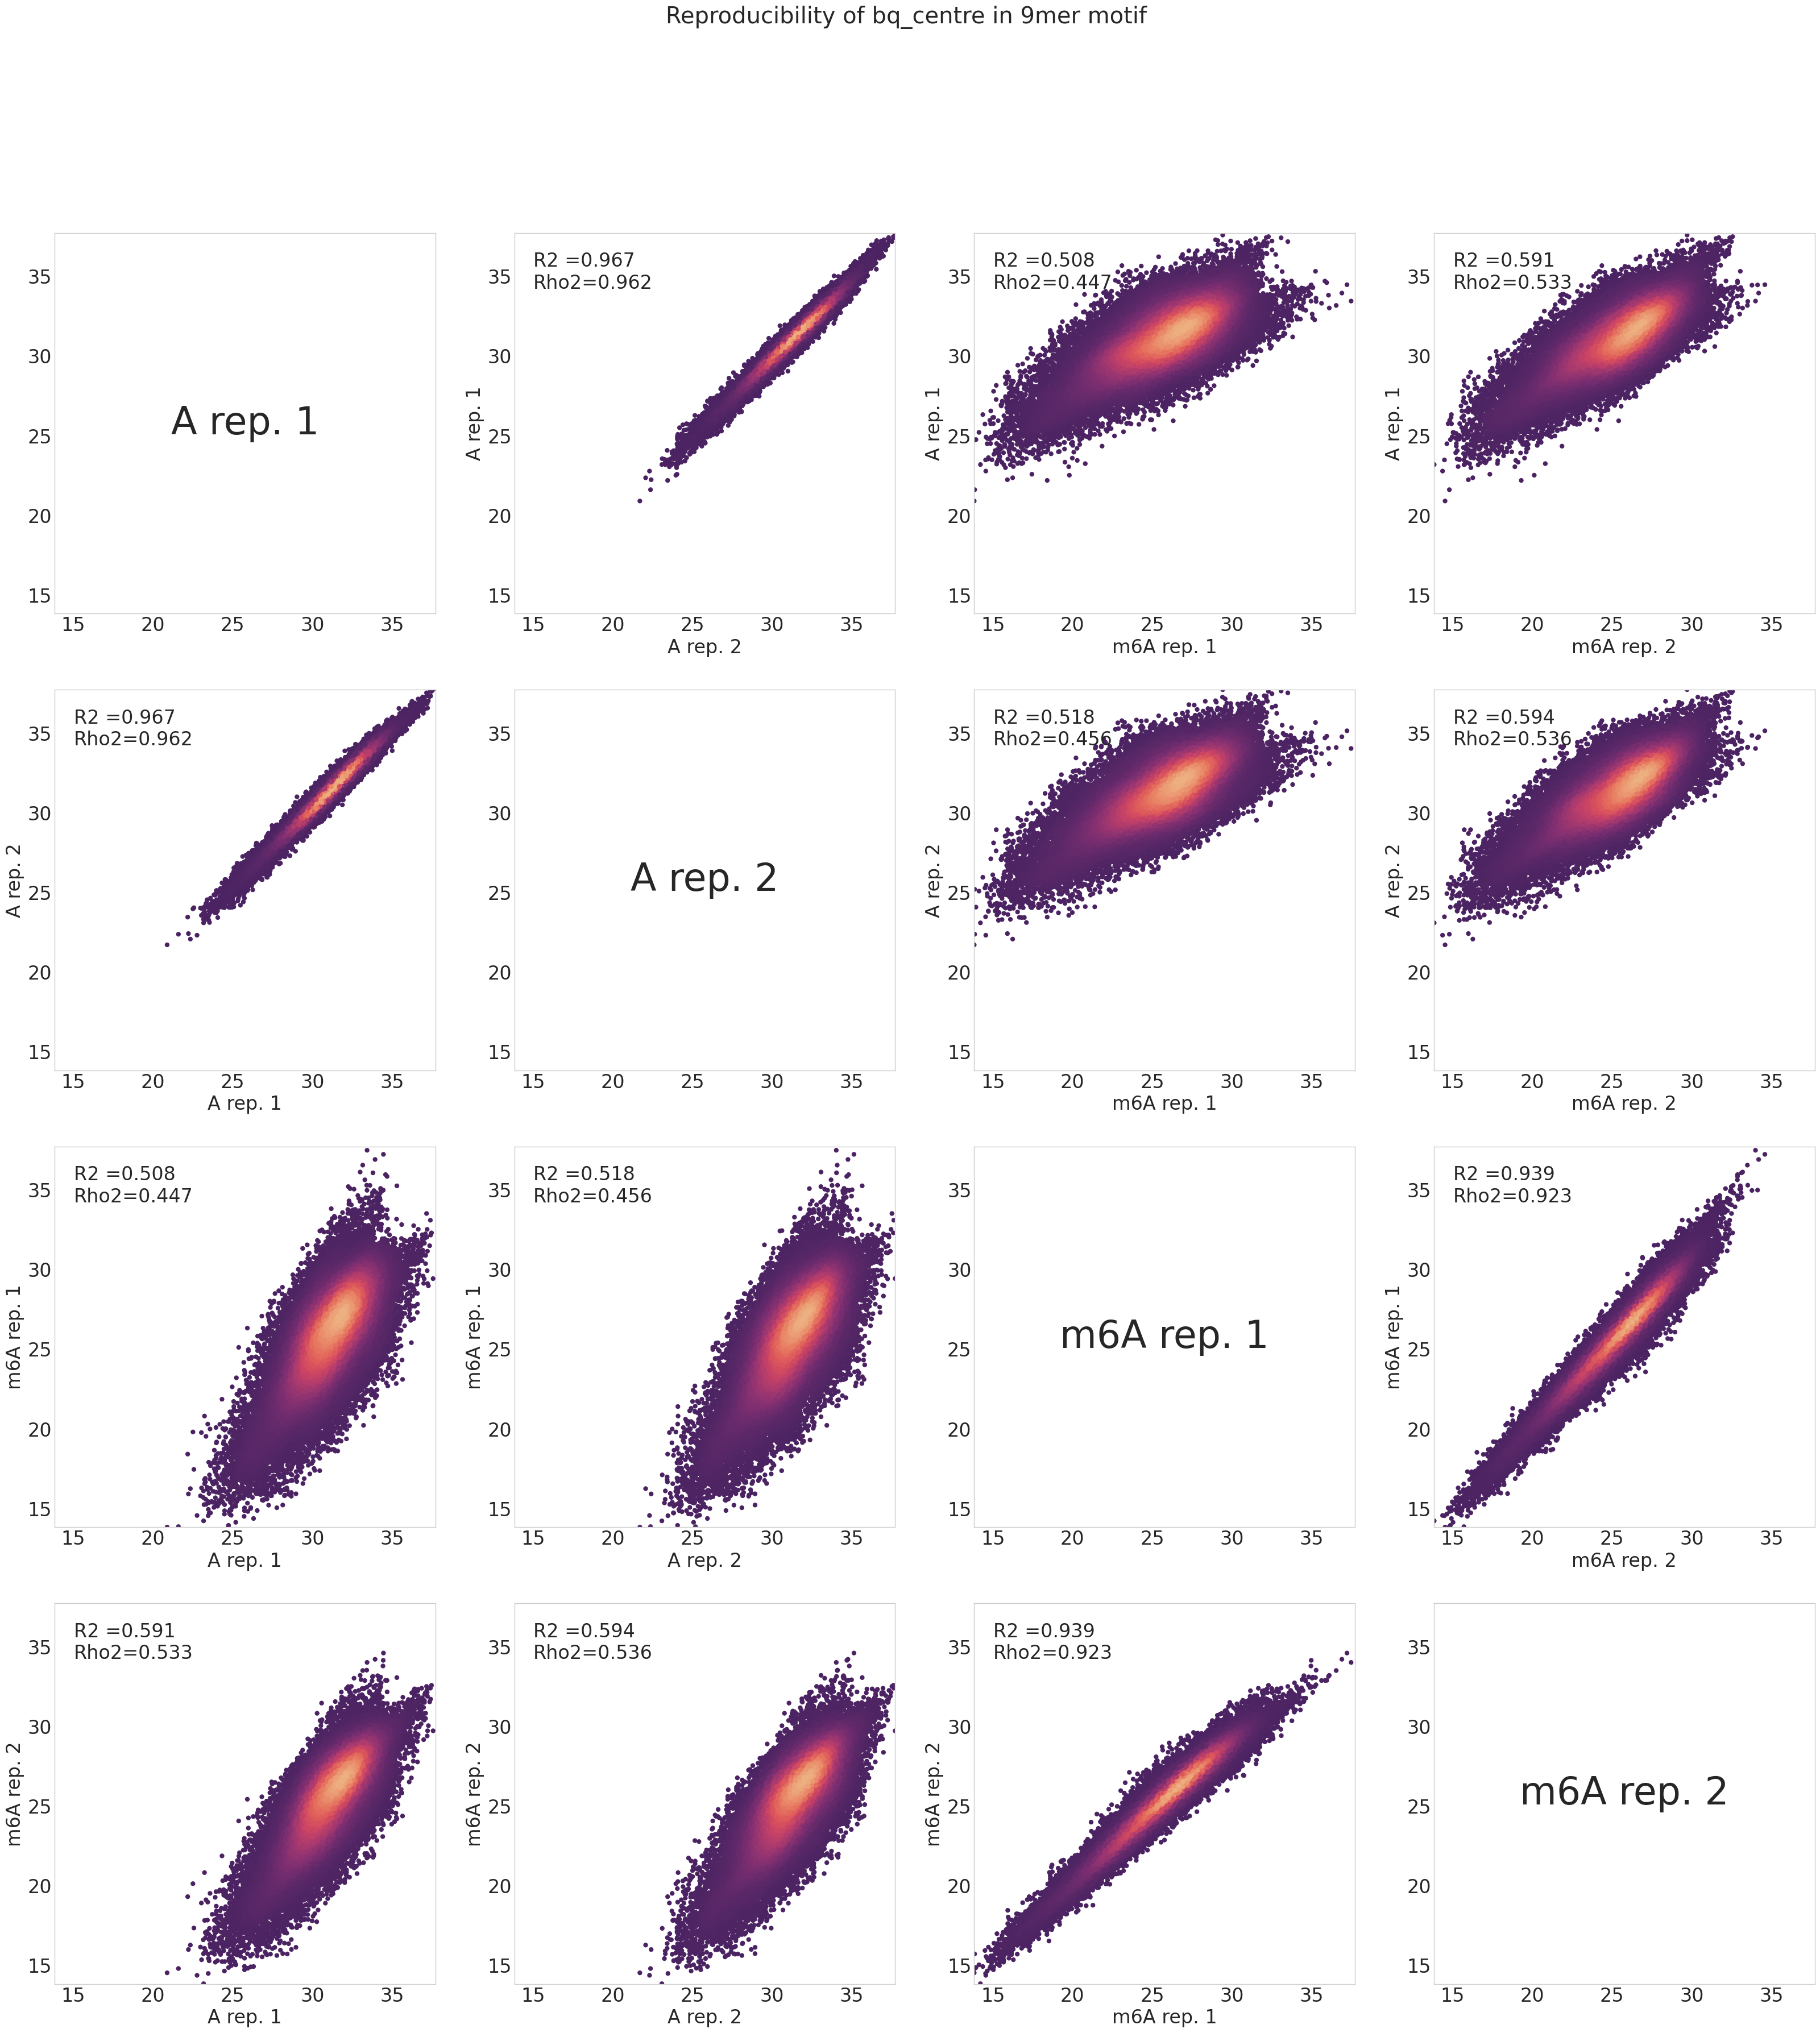

In [33]:
plot_all_combinations(dict_9mer, feature = "bq_centre", tick = 5)